In [31]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

In [32]:
def set_rc_params(fontsize=None):
    '''
    Set figure parameters
    '''

    if fontsize is None:
        fontsize = 16
    else:
        fontsize = int(fontsize)

    rc('font', **{'family': 'serif'})
    rc('text', usetex=True)

    plt.rcParams.update({'axes.linewidth': 1.3})
    plt.rcParams.update({'xtick.labelsize': fontsize})
    plt.rcParams.update({'ytick.labelsize': fontsize})
    plt.rcParams.update({'xtick.major.size': 8})
    plt.rcParams.update({'xtick.major.width': 1.3})
    plt.rcParams.update({'xtick.minor.visible': True})
    plt.rcParams.update({'xtick.minor.width': 1.})
    plt.rcParams.update({'xtick.minor.size': 6})
    plt.rcParams.update({'xtick.direction': 'out'})
    plt.rcParams.update({'ytick.major.width': 1.3})
    plt.rcParams.update({'ytick.major.size': 8})
    plt.rcParams.update({'ytick.minor.visible': True})
    plt.rcParams.update({'ytick.minor.width': 1.})
    plt.rcParams.update({'ytick.minor.size': 6})
    plt.rcParams.update({'ytick.direction': 'out'})
    plt.rcParams.update({'axes.labelsize': fontsize})
    plt.rcParams.update({'axes.titlesize': fontsize})
    plt.rcParams.update({'legend.fontsize': int(fontsize-2)})
    plt.rcParams['text.usetex'] = True
    plt.rcParams['text.latex.preamble'] = r'\usepackage{amssymb}'


set_rc_params(15)

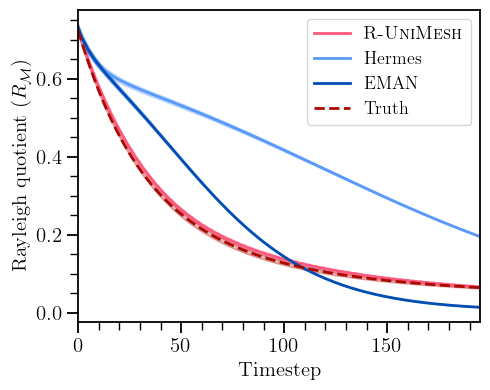

In [35]:
uni_pred = np.load('data/heat/armadillo/Uni/rayleigh_pred.npy')
uni_true = np.load('data/heat/armadillo/Uni/rayleigh_true.npy')
hermes_pred = np.load('data/heat/armadillo/Hermes/rayleigh_pred.npy')
eman_pred = np.load('data/heat/armadillo/EMAN/rayleigh_pred.npy')

mean_uni = np.mean(uni_pred, axis=0)
mean_hermes = np.mean(hermes_pred, axis=0)
mean_eman = np.mean(eman_pred, axis=0)
mean_true = np.mean(uni_true, axis=0)

std_uni = np.std(uni_pred, axis=0)
std_hermes = np.std(hermes_pred, axis=0)
std_eman = np.std(eman_pred, axis=0)
std_true = np.std(uni_true, axis=0)

timesteps = np.arange(mean_uni.shape[0])
fig, ax = plt.subplots(figsize=(5,4))

colors = [
    "#aa0800",
    "#004eb4",
    "#5899fb",
    "#ff587f",
]

ax.plot(timesteps, mean_uni, label=r'$\textsc{R-UniMesh}$', color=colors[3], linewidth=2)
ax.fill_between(timesteps, mean_uni - std_uni, mean_uni + std_uni,
                alpha=0.3, color=colors[3])

ax.plot(timesteps, mean_hermes, label='Hermes', color=colors[2], linewidth=2)
ax.fill_between(timesteps, mean_hermes - std_hermes, mean_hermes + std_hermes,
                alpha=0.3, color=colors[2])

ax.plot(timesteps, mean_eman, label='EMAN', color=colors[1], linewidth=2)
ax.fill_between(timesteps, mean_eman - std_eman, mean_eman + std_eman,
                alpha=0.3, color=colors[1])

ax.plot(timesteps, mean_true, label='Truth', color=colors[0], linewidth=2, linestyle='--')
ax.fill_between(timesteps, mean_true - std_true, mean_true + std_true,
                alpha=0.3, color=colors[0])

ax.set_xlabel('Timestep')
ax.set_ylabel(r'Rayleigh quotient ($R_\mathcal{M}$)')
ax.set_xlim(0, 195)
ax.legend()

plt.tight_layout()
plt.savefig('rayleigh_error_ribbons.png', dpi=500, bbox_inches='tight')